# Exploratory Data Analysis & Business Insights

## Objective

The objective of this notebook is to analyze the processed e-commerce sales dataset and answer key business questions related to product performance, regional performance, customer segments, discounts, and sales trends.

The insights generated from this analysis can help support data-driven business decisions.

## Import Required Libraries

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Processed Dataset

In [103]:
df = pd.read_csv("/content/ecommerce_feature_engineered (2).csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Shipping Days,Profit Margin,Discount Rate
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.96,2,0.00,41.91,2016,11,4,3,16.00,0.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.94,3,0.00,219.58,2016,11,4,3,30.00,0.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.62,2,0.00,6.87,2016,6,2,4,47.00,0.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.58,5,0.45,-383.03,2015,10,4,7,-40.00,45.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.37,2,0.20,2.52,2015,10,4,7,11.25,20.00


## Dataset Ready for Analysis

The cleaned dataset is loaded successfully and is now ready for exploratory data analysis.

In [104]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Quarter', 'Shipping Days', 'Profit Margin', 'Discount Rate'],
      dtype='object')

##**1. DATASET AND DISTRIBUTION OVERVIEW**

###**1.1 Numerical Summary** -  Before analyzing business performance, what does the data actually look like?

In [105]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe().T.style.background_gradient(
    cmap='plasma'
)

,count,mean,std,min,25%,50%,75%,max
Sales,9994.000000,229.858001,623.245101,0.444000,17.280000,54.490000,209.940000,22638.480000
Quantity,9994.000000,3.789574,2.225110,1.000000,2.000000,3.000000,5.000000,14.000000
Discount,9994.000000,0.156203,0.206452,0.000000,0.000000,0.200000,0.200000,0.800000
Profit,9994.000000,28.656896,234.260108,-6599.978000,1.728750,8.666500,29.364000,8399.976000


###**1.2 - Sales Distribution** Understanding the distribution of sales helps identify the typical order value and determine whether the dataset contains unusually high-value transactions.


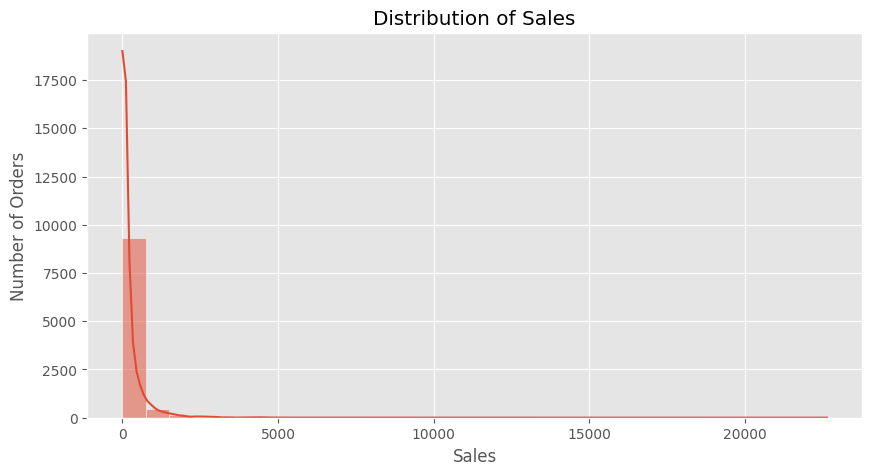

In [106]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Sales",
    bins=30,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.show()

* ***The Sales distribution is highly right-skewed, with most orders concentrated at relatively low sales values***
* ***A small number of orders have very high sales values, creating a long tail extending beyond 20,000.***
* ***This indicates the presence of extreme/high-value observations (potential outliers) that may strongly influence the mean and other statistical measures.***

**Sales Outliers**

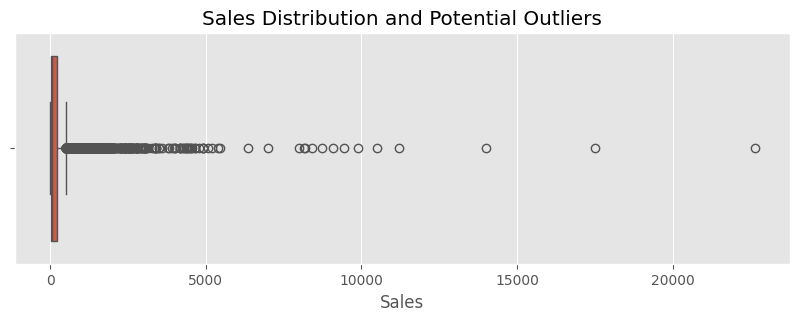

In [107]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="Sales"
)

plt.title("Sales Distribution and Potential Outliers")
plt.xlabel("Sales")
plt.show()

***Sales is highly right-skewed, with most values concentrated at the lower end and numerous high-value potential outliers.***

##

### **1.2- Profit Distribution** - Profit distribution helps us understand how profitability varies across individual transactions and whether the dataset contains unusually high or negative profit values.

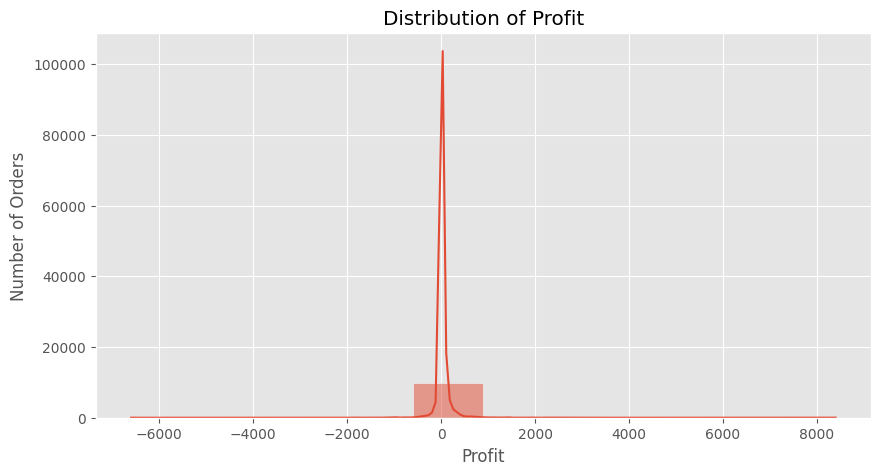

In [108]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Profit",
    bins=10,
    kde=True
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")
plt.show()

* ***The presence of negative Profit values indicates that some transactions result in losses, while the concentration of values around zero shows that most transactions have relatively low profit margins***
* ***Also a small number of transactions contribute disproportionately high profits or losses which suggests the need to investigate the products, customers, discounts and segments driving these extreme outcomes***


### **1.3 Quantity Distribution** - Quantity analysis helps us understand the typical number of units purchased per transaction and identify whether orders with unusually large quantities are present.

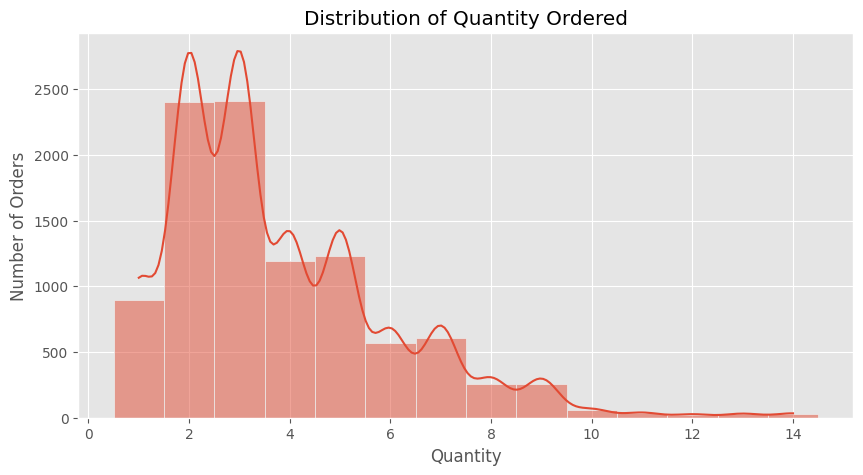

In [109]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Quantity",
    bins=20,
    discrete=True,
    kde = True
)

plt.title("Distribution of Quantity Ordered")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.show()

* ***The highest bars are around Quantity = 2 and 3 which means orders of 2–3 items occur most frequently***
* ***The frequency decreases as order quantity increases, indicating that large-quantity orders are relatively uncommon***

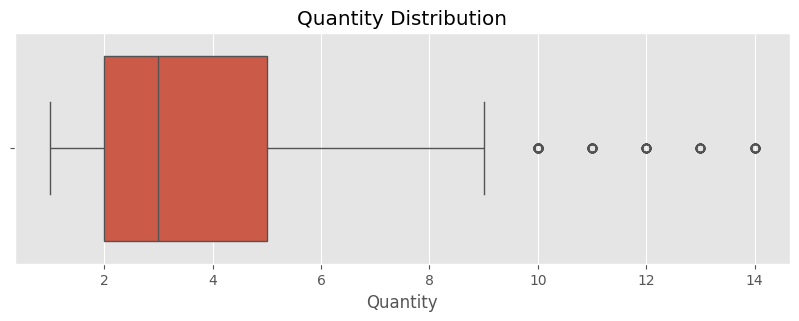

In [110]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x="Quantity"
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.show()

* ***The median quantity is around 3 units, with most orders falling between 2 and 5 units. A few higher quantities (10–14 units) appear as potential outliers, indicating that large-quantity orders are relatively uncommon***

### **1.4 Discount Distribution** - Discount analysis provides an initial understanding of the pricing concessions applied across transactions. This establishes a baseline for investigating whether higher discounts are associated with changes in profitability.

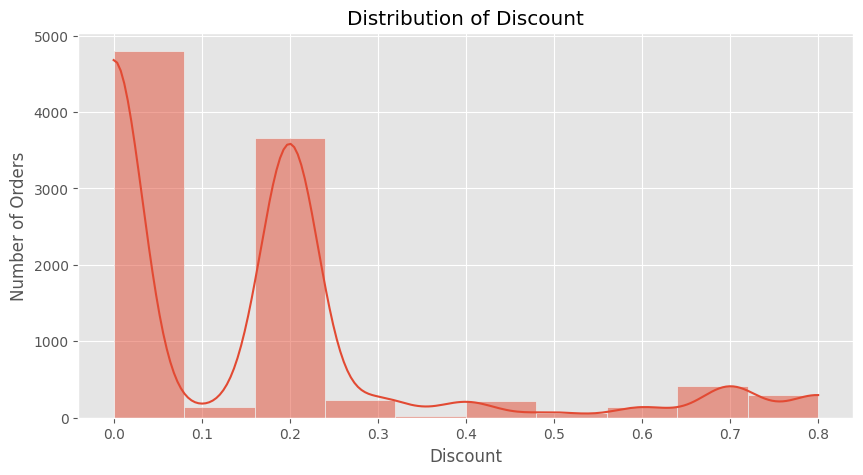

In [111]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Discount",
    bins=10,
    kde=True
)

plt.title("Distribution of Discount")
plt.xlabel("Discount")
plt.ylabel("Number of Orders")
plt.show()

***Discounts are concentrated mainly at 0% and 20%, while higher discount levels are less frequent, indicating that substantial discounts are applied to a relatively smaller proportion of orders***

---



**Correlation Matrix**

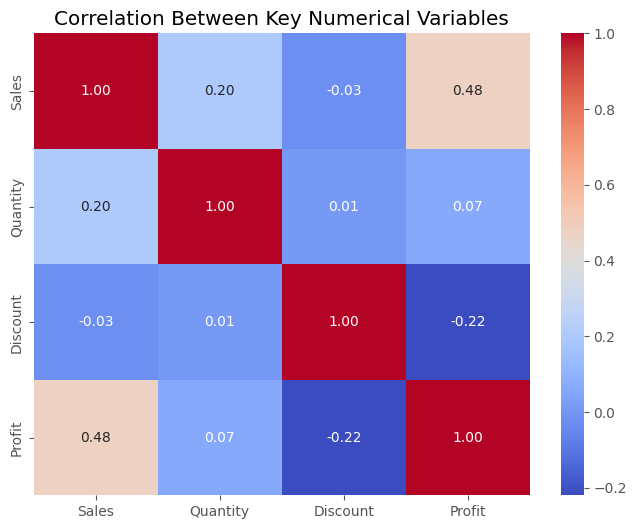

In [112]:
correlation_matrix = df[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Key Numerical Variables")
plt.show()

***The correlation analysis shows a moderate positive relationship between Sales and Profit (0.48), while Discount has a weak negative relationship with Profit (-0.22). Quantity shows very weak correlations with both Sales and Profit, suggesting that these variables have limited linear relationships with each other***

---



# **2. PRODUCT PERFORMANCE**
###This section evaluates the performance of product categories and sub-categories to identify which products contribute the most to sales and profitability

### **2.1 - Category wise Sales & Profit**

In [113]:
category_performance = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Sales", ascending=False)

category_performance

,Sales,Profit
Category,,
Technology,"836,154.03","145,454.95"
Furniture,"741,999.80","18,451.27"
Office Supplies,"719,047.03","122,490.80"


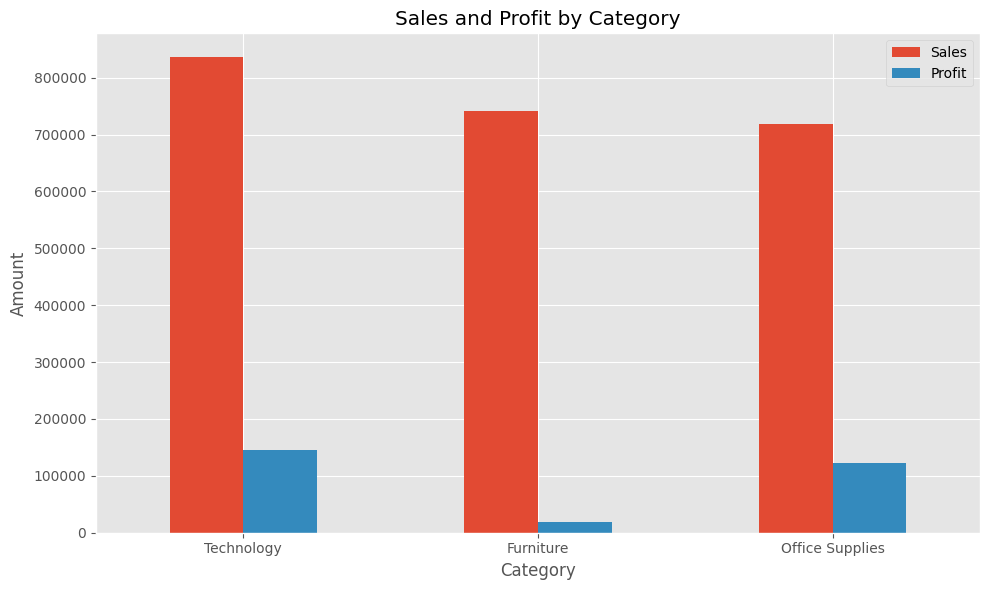

In [114]:
category_performance.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

####***Technology leads in both Sales and Profit, while Furniture generates substantial Sales but comparatively low Profit, indicating weak profitability. Office Supplies, despite lower Sales than Furniture, generates significantly higher Profit***

####***This highlights that sales volume alone does not determine profitability***


### **2.1 - Profit Margin By Category** -
### While total Profit helps measure the overall profitability of a category, it does not account for the level of Sales generated.
### Profit Margin provides a relative measure of profitability by showing how much profit is generated from each unit of sales


In [115]:
category_performance["Profit Margin (%)"] = (
    category_performance["Profit"] /
    category_performance["Sales"]
) * 100

category_performance.sort_values(
    "Profit Margin (%)",
    ascending=False
)

,Sales,Profit,Profit Margin (%)
Category,,,
Technology,"836,154.03","145,454.95",17.40
Office Supplies,"719,047.03","122,490.80",17.04
Furniture,"741,999.80","18,451.27",2.49


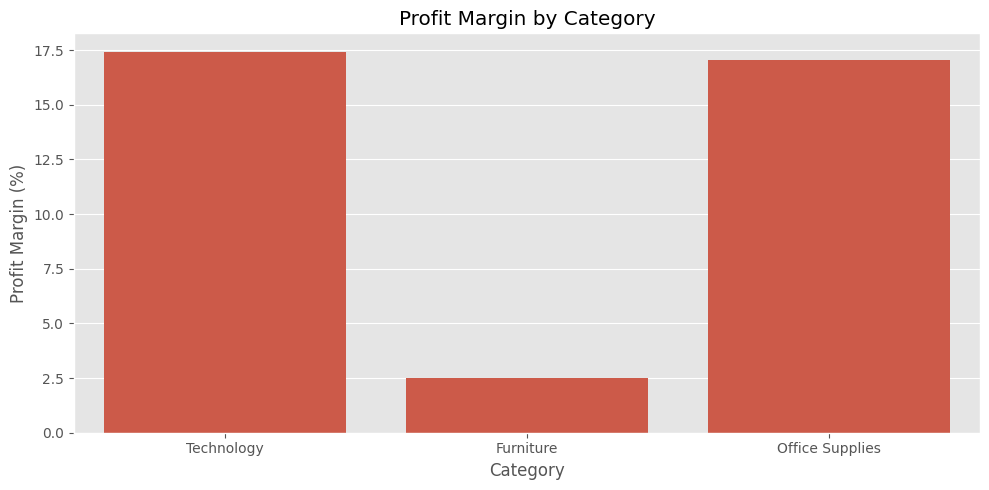

In [116]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_performance.reset_index(),
    x="Category",
    y="Profit Margin (%)"
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

####* ***The profit margin gives us a better comparison than total profit because it considers Profit relative to Sales.***
####* ***Profit margins vary considerably across categories, with Technology and Office Supplies showing similar margins of around 17%, while Furniture has a substantially lower margin of approximately 2.5%, indicating differences in profitability efficiency across categories***
####* ***The key insight is that high Sales do not necessarily mean high profit margin***

###  **2.3 - Sub Category Performance** Category level analysis can hide differences between individual product groups.
###Therefore, the analysis is further broken down into sub-categories to identify which product groups contribute most to sales and profit.

In [117]:
subcategory_performance = df.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).sort_values("Sales", ascending=False)

subcategory_performance

,Sales,Profit
Sub-Category,,
Phones,"330,007.05","44,515.73"
Chairs,"328,449.10","26,590.17"
Storage,"223,843.61","21,278.83"
Tables,"206,965.53","-17,725.48"
Binders,"203,412.73","30,221.76"
Machines,"189,238.63","3,384.76"
Accessories,"167,380.32","41,936.64"
Copiers,"149,528.03","55,617.82"
Bookcases,"114,880.00","-3,472.56"


**Sales And Profit Visualisation**

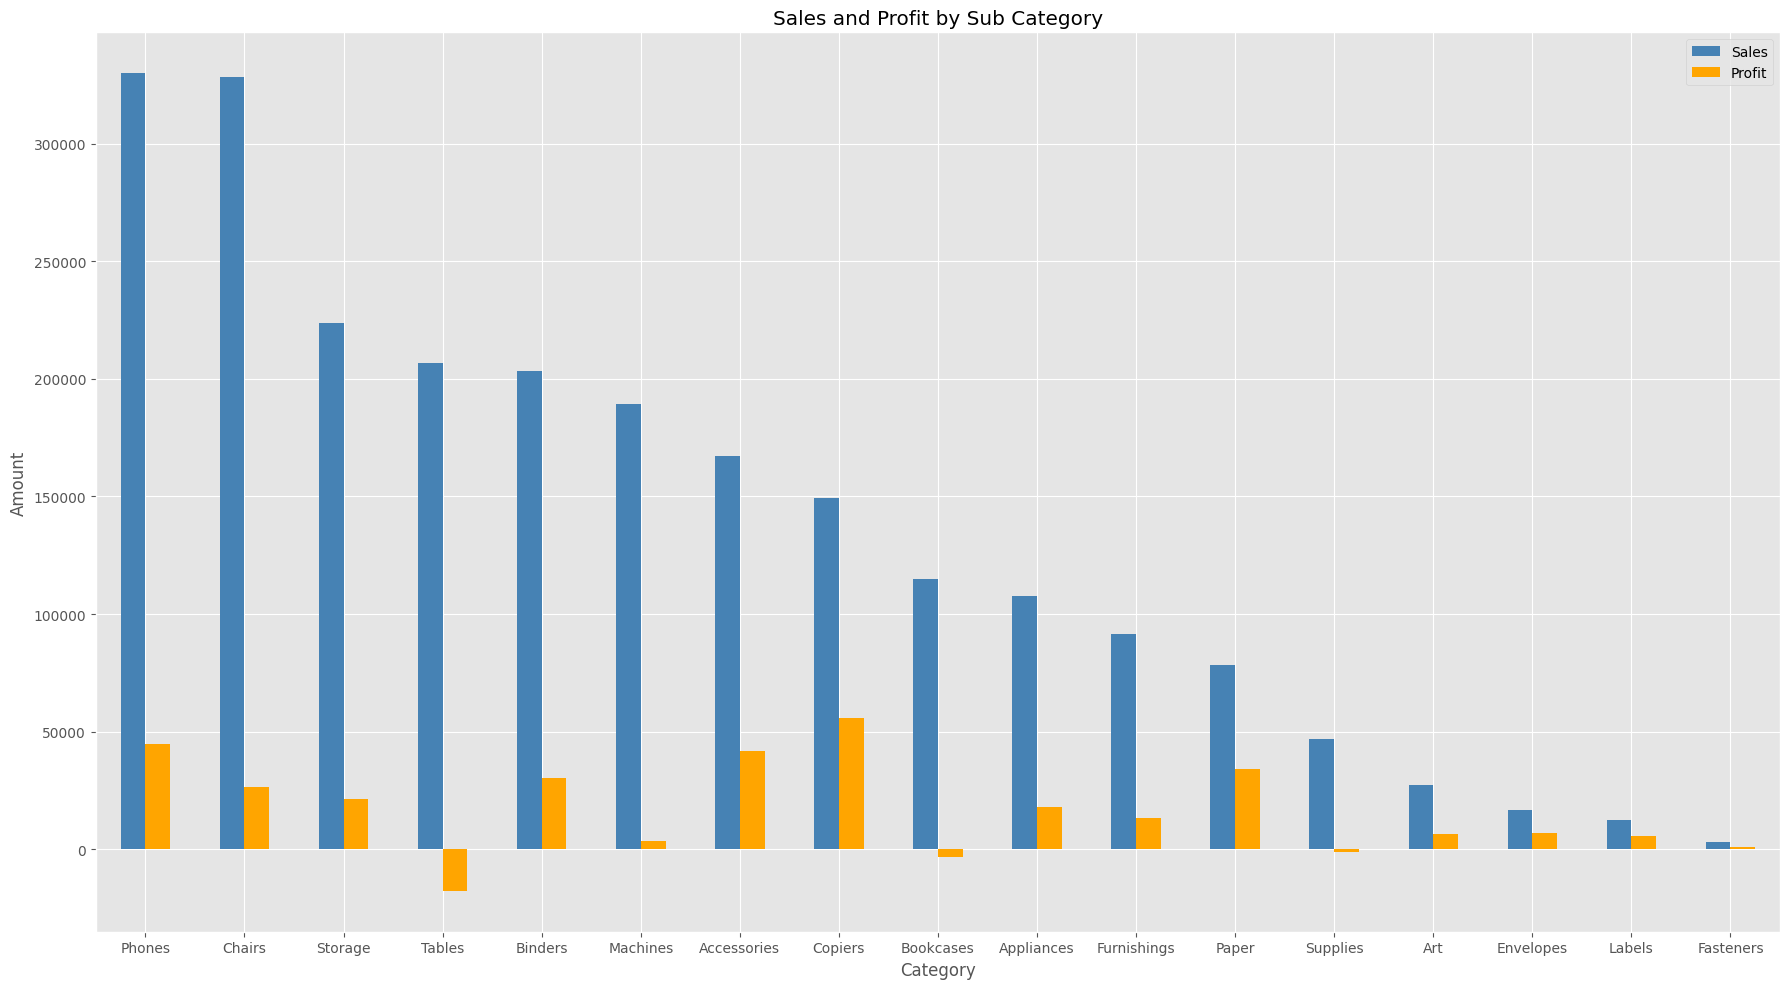

In [118]:
subcategory_performance.plot(
    kind="bar",
    figsize=(18, 10),
    color=['steelblue', 'orange']
)

plt.title("Sales and Profit by Sub Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

####***While Phones and Chairs are major sales contributors, categories such as Copiers and Paper demonstrate stronger profit generation relative to their sales, whereas Tables exhibit high sales but significant losses.***



**PROFIT MARGIN %**

In [119]:
subcategory_performance["Profit Margin (%)"] = (
    subcategory_performance["Profit"] /
    subcategory_performance["Sales"]
) * 100

subcategory_performance.sort_values(
    "Profit Margin (%)",
    ascending=False
)

,Sales,Profit,Profit Margin (%)
Sub-Category,,,
Labels,"12,486.31","5,546.25",44.42
Paper,"78,479.21","34,053.57",43.39
Envelopes,"16,476.40","6,964.18",42.27
Copiers,"149,528.03","55,617.82",37.20
Fasteners,"3,024.28",949.52,31.40
Accessories,"167,380.32","41,936.64",25.05
Art,"27,118.79","6,527.79",24.07
Appliances,"107,532.16","18,138.01",16.87
Binders,"203,412.73","30,221.76",14.86


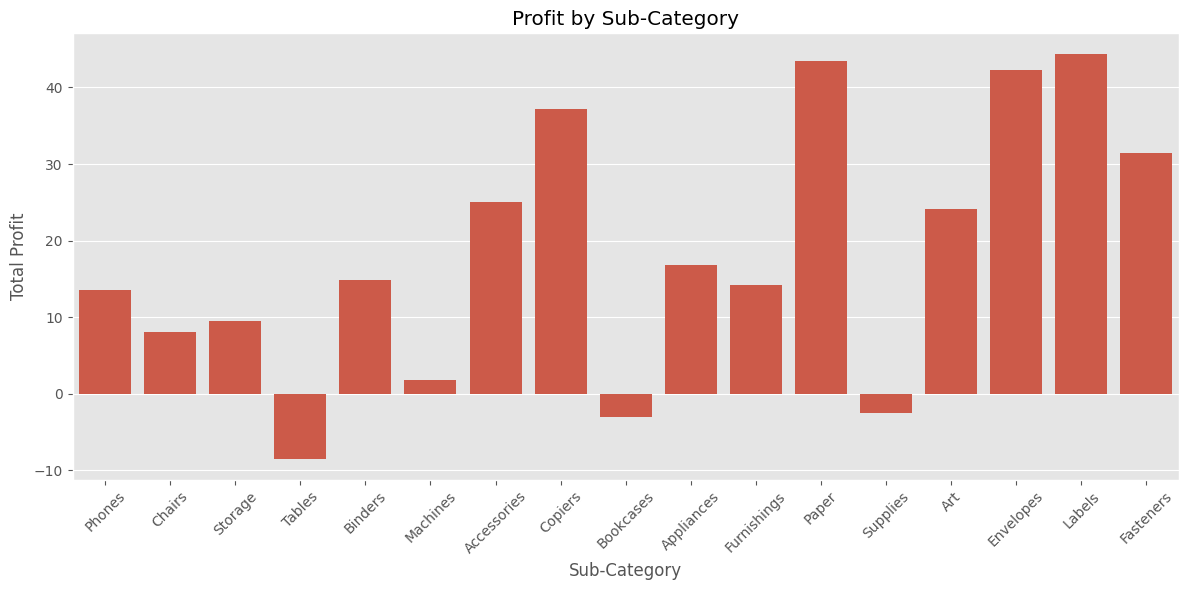

In [120]:
subcategory_performance["Profit Margin (%)"] = (
    subcategory_performance["Profit"] /
    subcategory_performance["Sales"]
) * 100

plt.figure(figsize=(12, 6))

sns.barplot(
    data=subcategory_performance.reset_index(),
    x="Sub-Category",
    y="Profit Margin (%)"
)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


***The company’s profitability is concentrated in a few sub-categories such as Labels, Paper, Envelopes, and Copiers, while Tables, Bookcases, and Supplies negatively impact overall profitability***

##**Business Question**
##**Q.1 - Which sub-categories are the major contributors to overall profit, and which sub-categories are generating losses?**
##**Answer - Profit is primarily driven by Labels, Paper, Envelopes, Copiers, and Accessories, while Tables, Bookcases, and Supplies are loss-making. Tables represent the most significant profitability concern and may require further investigation into pricing, discounts, and costs**

**Follow-up business questions**
* **Why are Tables generating losses despite being a major sales category?**
* **What discount levels are associated with the loss-making sub-categories?**
* **Are losses concentrated in specific customer segments or regions?**

---



---







## **3. CUSTOMER ANALYSIS**

### **3.1 Customer Segment Analysis** -Customer segmentation provides an initial understanding of how different customer groups contribute to sales and profitability.
###Comparing sales, profit and discount across segments helps identify differences in customer value and purchasing behavior.

In [121]:
segment_performance = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Average_Discount=("Discount", "mean")
).sort_values("Sales", ascending=False)

segment_performance

,Sales,Profit,Average_Discount
Segment,,,
Consumer,"1,161,401.34","134,119.21",0.16
Corporate,"706,146.37","91,979.13",0.16
Home Office,"429,653.15","60,298.68",0.15


* ***The segment-wise analysis shows that Consumer generates the highest Sales and Profit, followed by Corporate and Home Office.***
* ***Average discounts are relatively similar across the three segments, suggesting that differences in segment performance cannot be explained by average discount alone.***

<Figure size 1000x600 with 0 Axes>

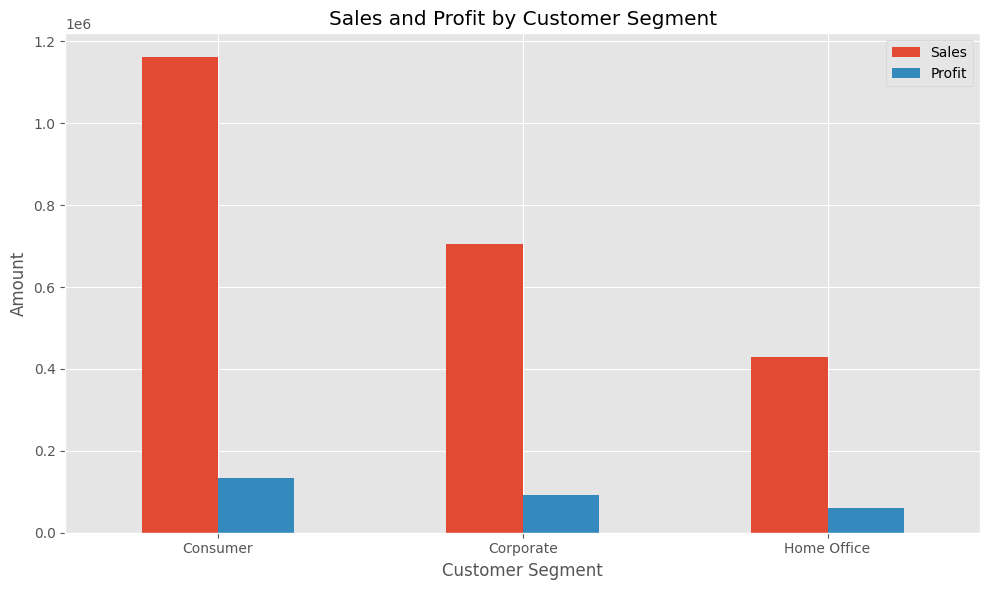

In [122]:
plt.figure(figsize=(10, 6))

segment_performance[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

### **3.2 - Customer Level Sales & Profitibality** - Customer-level analysis examines Sales, Profit, and order frequency at the individual customer level to identify high-value customers and potentially unprofitable customer relationships.

In [123]:
customer_performance = df.groupby(
    ["Customer ID", "Customer Name"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique")
).sort_values("Profit", ascending=False)

customer_performance.head()

,,Sales,Profit,Orders
Customer ID,Customer Name,,,
TC-20980,Tamara Chand,"19,052.22","8,981.32",5
RB-19360,Raymond Buch,"15,117.34","6,976.10",6
SC-20095,Sanjit Chand,"14,142.33","5,757.41",9
HL-15040,Hunter Lopez,"12,873.30","5,622.43",6
AB-10105,Adrian Barton,"14,473.57","5,444.81",10


***High-value customers are not necessarily those with the highest order frequency. "Tamara Chand" generates the highest profit with only 5 orders, while "Adrian Barton" has 10 orders but considerably lower total profit, highlighting differences in customer value and profitability per order***

### **3.3 - Average Order Value**- Total Sales and order frequency provide an overall view of customer activity, but they do not indicate the typical value of each order.
###Average Order Value (AOV) is therefore calculated to understand the average Sales generated per order for each customer and identify differences in customer purchasing behaviour (whether customers tend to place small or large orders)

###The formula is:

###**AOV = Total Sales ÷ Number of Orders**

In [124]:
customer_performance["Average Order Value"] = (
    customer_performance["Sales"] /
    customer_performance["Orders"]
)
customer_performance.sort_values(
    "Average Order Value",
    ascending=False
).head(10)


,,Sales,Profit,Orders,Average Order Value
Customer ID,Customer Name,,,,
SM-20320,Sean Miller,"25,043.05","-1,980.74",5,"5,008.61"
TC-20980,Tamara Chand,"19,052.22","8,981.32",5,"3,810.44"
TA-21385,Tom Ashbrook,"14,595.62","4,703.79",4,"3,648.91"
GT-14635,Grant Thornton,"9,351.21","-4,108.66",3,"3,117.07"
BM-11140,Becky Martin,"11,789.63","-1,659.96",4,"2,947.41"
MW-18235,Mitch Willingham,"5,253.88","1,665.52",2,"2,626.94"
RB-19360,Raymond Buch,"15,117.34","6,976.10",6,"2,519.56"
CC-12370,Christopher Conant,"12,129.07","2,177.05",5,"2,425.81"
PF-19120,Peter Fuller,"9,062.86",-614.29,4,"2,265.72"


***High AOV does not guarantee profitability; some customers generate substantial order values while still producing losses, indicating potential pricing, discount, or cost-related issue***

###**Business Question**
### ***Q. Why are some customers with high Average Order Values generating losses?**

---



### **3.4 - Customer Concentration / Pareto Analysis**
###**Pareto Analysis - Pareto Analysis is a technique used to identify the small number of customers, products, or factors that contribute a large proportion of the total business outcome.**


In [125]:
# Step 1: Sort customers by Sales
customer_pareto = customer_performance.sort_values(
    "Sales",
    ascending=False
).reset_index(drop=True)


In [126]:

# Step 2: Calculate cumulative Sales
customer_pareto["Cumulative Sales"] = (
    customer_pareto["Sales"].cumsum()
)


In [127]:
# Step 3: Calculate cumulative Sales %
total_sales = customer_pareto["Sales"].sum()

customer_pareto["Cumulative Sales %"] = (
    customer_pareto["Cumulative Sales"] / total_sales
) * 100


In [128]:
# Step 4: Calculate Customer %
customer_pareto["Customer %"] = (
    (customer_pareto.index + 1) / len(customer_pareto)
) * 100

customer_pareto.head()

,Sales,Profit,Orders,Average Order Value,Cumulative Sales,Cumulative Sales %,Customer %
0,"25,043.05","-1,980.74",5,"5,008.61","25,043.05",1.09,0.13
1,"19,052.22","8,981.32",5,"3,810.44","44,095.27",1.92,0.25
2,"15,117.34","6,976.10",6,"2,519.56","59,212.61",2.58,0.38
3,"14,595.62","4,703.79",4,"3,648.91","73,808.23",3.21,0.50
4,"14,473.57","5,444.81",10,"1,447.36","88,281.80",3.84,0.63


In [129]:
customer_pareto.head()

,Sales,Profit,Orders,Average Order Value,Cumulative Sales,Cumulative Sales %,Customer %
0,"25,043.05","-1,980.74",5,"5,008.61","25,043.05",1.09,0.13
1,"19,052.22","8,981.32",5,"3,810.44","44,095.27",1.92,0.25
2,"15,117.34","6,976.10",6,"2,519.56","59,212.61",2.58,0.38
3,"14,595.62","4,703.79",4,"3,648.91","73,808.23",3.21,0.50
4,"14,473.57","5,444.81",10,"1,447.36","88,281.80",3.84,0.63


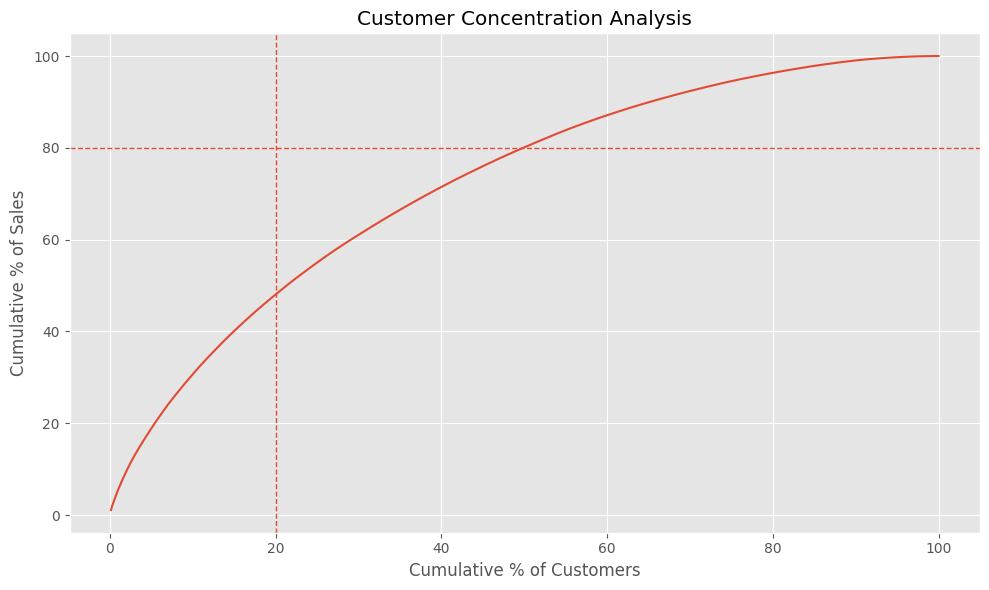

In [130]:
plt.figure(figsize=(10, 6))

plt.plot(
    customer_pareto["Customer %"],
    customer_pareto["Cumulative Sales %"]
)

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Sales")
plt.title("Customer Concentration Analysis")

plt.axhline(80, linestyle="--", linewidth=1)
plt.axvline(20, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

#### **"The vertical line marks the top 20% of customers, while the horizontal line marks 80% of total Sales. Together, they provide the standard Pareto benchmark for assessing customer concentration".**

***Key Insight -***
* ***The top 20% of customers account for about 48% of total Sales.***
* ***The top 50% of customers generate 80% of total Sales.***
* ***It shows that the data does not follow the classic 20% → 80% pattern.***
* ***This indicates that Sales are moderately concentrated among high-value customers but are not dominated by a very small customer group.***

In [131]:
customer_pareto[
    customer_pareto["Cumulative Sales %"] >= 80
].head(1)

,Sales,Profit,Orders,Average Order Value,Cumulative Sales,Cumulative Sales %,Customer %
395,"2,258.19",195.45,8,282.27,"1,839,080.07",80.06,49.94


### **BUSINESS QUESTION**
### **Q1. Business Question - Is the company's Sales concentrated among a relatively small group of customers, or is Sales distributed more evenly across customers?**
### ***Answer*** - *Sales show a moderate level of customer concentration, with 50% of customers contributing approximately 80% of total sales. This indicates that sales are distributed across a relatively broad customer base rather than being heavily dependent on a very small group of customers*

### **Q2. How concentrated is the company's Sales among its customers, and what proportion of customers is required to generate 80% of total Sales"?***
### ***Answer*** - *Sales are moderately concentrated: the top 20% of customers generate about 49.94% of Sales, while around 50% of customers account for 80% of total Sales.*


---



---



## **3.5 - RFM Customer Segmentation**/ **CUSTOMER LEVEL BEHAVIORAL ANALYSIS**

### **Step 1 - Converting Data Type from object to datetime**

In [132]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

## **Step 2 - Setting up Analysis Date**

In [133]:
analysis_date = df['Order Date'].max()

**"This prepares the data to measure customer Recency"**

## **Step 3 - Calculating RFM**
* **Creating customer - level dataset**

In [134]:
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (analysis_date - x.max()).days,       # RECENCY
    'Order ID': 'nunique',                                        # FREQUENCY
    'Sales': 'sum'                                                # MONETARY
}).sort_values(
    ['Order Date', 'Order ID', 'Sales'],
    ascending=[False, False, False]
)


* **Renaming columns to RFM**

In [135]:
# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']


In [136]:
rfm = rfm.reset_index()        # to bring 'Customer ID' back as a column

In [137]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,NB-18580,1165,2,273.87
1,GR-14560,1135,2,"1,284.38"
2,RE-19405,1097,1,48.36
3,CM-12715,1035,4,"3,984.45"
4,VT-21700,1000,2,"1,736.60"


* **Assigning score to each RFM component**

In [138]:
# RFM scores
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),    # .rank - gives each customer a unique ranking before creating the five groups.
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

# Combine scores to form RFM Score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,NB-18580,1165,2,273.87,1,1,1,111
1,GR-14560,1135,2,"1,284.38",1,1,2,112
2,RE-19405,1097,1,48.36,1,1,1,111
3,CM-12715,1035,4,"3,984.45",1,1,4,114
4,VT-21700,1000,2,"1,736.60",1,1,2,112


In [139]:
rfm['RFM_Score'].value_counts().sort_index(ascending=False)

,count
RFM_Score,
555,22
554,13
553,11
552,3
545,13
...,...
115,2
114,5
113,11


## **Step 4 - Segmentation of customers based on RFM scores**

###**To streamline the analysis the customers were divided into exactly four customer segments, consolidating the RFM scores into broad, highly actionable groups**

| Segment                   | Recency | Frequency / Monetary | Meaning                           |
| ------------------------- | ------- | -------------------- | --------------------------------- |
|  **Core Loyalists**     | 4–5     | High                 | Recent + strong engagement/value  |
|  **New & Growing**       | 4–5     | F = 1–2              | Recent but not frequent yet       |
|  **At-Risk**            | 1–2     | F or M = 3–5         | Previously valuable, now inactive |
|  **Hibernating / Lost** | 1–2     | F and M = 1–2        | Inactive + low value              |


In [140]:

rfm['R_Score'] = rfm['R_Score'].astype(int)                                      # Convert RFM scores to integers
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)



rfm['Customer Segment'] = ''                                                      # Create the Customer Segment column


# 1. Core Loyalists
# Recent + frequent + high monetary value
rfm.loc[
    (rfm['R_Score'] >= 4) &
    (rfm['F_Score'] >= 4) &
    (rfm['M_Score'] >= 4),
    'Customer Segment'
] = 'Core Loyalists'


# 2. New & Growing
# Recent customers who are not yet high-frequency AND high-value
rfm.loc[
    (rfm['R_Score'] >= 4) &
    ~(
        (rfm['F_Score'] >= 4) &
        (rfm['M_Score'] >= 4)
    ),
    'Customer Segment'
] = 'New & Growing'


# 3. At-Risk
# Not recent, but still frequent OR high-value
rfm.loc[
    (rfm['R_Score'] <= 3) &
    (
        (rfm['F_Score'] >= 4) |
        (rfm['M_Score'] >= 4)
    ),
    'Customer Segment'
] = 'At-Risk'


# 4. Hibernating / Lost
# Not recent + low frequency + low monetary value
rfm.loc[
    (rfm['R_Score'] <= 3) &
    (rfm['F_Score'] <= 3) &
    (rfm['M_Score'] <= 3),
    'Customer Segment'
] = 'Hibernating / Lost'


# Check the distribution
print(rfm['Customer Segment'].value_counts())

Customer Segment
Hibernating / Lost    259
At-Risk               216
New & Growing         207
Core Loyalists        111
Name: count, dtype: int64


##**Decision Tree for RFM segmentation**
                 Is R ≥ 4?
                /         \
              YES          NO
               |            |
       Is F ≥4 AND M ≥4?   Is F ≥4 OR M ≥4?
          /       \          /          \
        YES       NO       YES          NO
         |         |         |            |
       CORE      NEW &      AT-RISK    HIBERNATING
      LOYALIST   GROWING                 / LOST

##**Customer Segments**

In [141]:
segment_customers = rfm['Customer Segment'].value_counts()
segment_customers.head()

,count
Customer Segment,
Hibernating / Lost,259
At-Risk,216
New & Growing,207
Core Loyalists,111


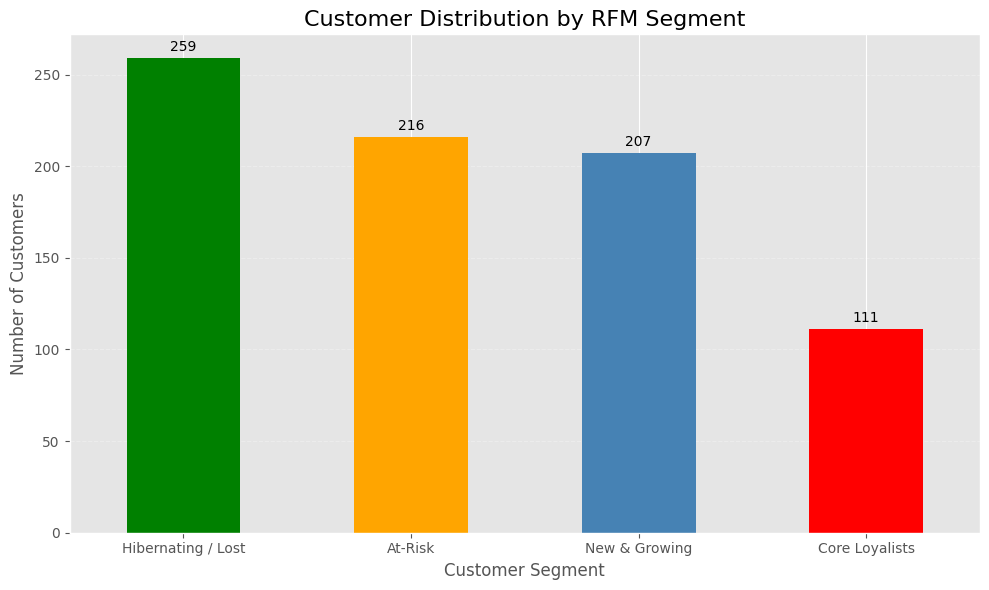

In [142]:
plt.figure(figsize=(10, 6))

ax = segment_customers.plot(
    kind='bar',
    color=['green', 'orange', 'steelblue', 'red']
)

plt.title("Customer Distribution by RFM Segment", fontsize=16)
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()




## Segment-wise Business Insights

| RFM Segment | Customers | Avg. Recency (Days) | Avg. Frequency | Avg. Monetary Value | Key Business Insight |
|---|---:|---:|---:|---:|---|
| **Core Loyalists** | **111** | **24.71** | **9.21** | **5,221.45** | These customers are the most valuable and engaged segment, combining recent purchases, the highest purchase frequency, and the highest average monetary value. |
| **At-Risk** | **194** | **258.25** | **6.70** | **3,534.22** | This is a sizeable group of relatively high-value and frequent customers who have not purchased recently, indicating a significant risk of customer churn. |
| **New & Growing** | **79** | **28.08** | **4.05** | **1,758.73** | These customers have purchased recently but have lower frequency and monetary value than Core Loyalists, indicating potential for future customer development. |
| **Hibernating / Lost** | **122** | **378.63** | **3.45** | **794.14** | These customers have the longest time since their last purchase, the lowest purchase frequency, and the lowest monetary value, indicating weak current engagement. |

## Overall Business Insight

> **RFM analysis identifies Core Loyalists as the highest-value and most engaged segment, while At-Risk customers represent the most significant retention opportunity because they have relatively high monetary value but declining recency. New & Growing customers provide an opportunity for future value creation, whereas Hibernating / Lost customers require selective, low-cost reactivation strategies.**

## RFM Business Recommendations

### Core Loyalists : Retain & Reward
- Strengthen customer loyalty through loyalty programs and personalized offers.
- Encourage cross-selling and premium product purchases.
- Provide early access to new products or special promotions.

### At-Risk : Win Back
- Launch targeted reactivation and win-back campaigns.
- Offer personalized incentives based on previous purchasing behavior.
- Investigate the reasons behind declining purchase activity.

### New & Growing : Develop
- Encourage repeat purchases through personalized product recommendations.
- Use cross-selling and complementary product offers.
- Provide incentives for second and subsequent purchases.

### Hibernating / Lost : Selective Reactivation
- Use low-cost reactivation campaigns.
- Prioritize customers who had higher historical monetary value.
- Avoid excessive promotional spending on consistently low-value inactive customers.

## **Customer Segment Wise Spending**

In [143]:
segment_sales = rfm.groupby('Customer Segment')['Monetary'].sum()
segment_sales.head()

,Monetary
Customer Segment,
At-Risk,"955,808.19"
Core Loyalists,"579,581.12"
Hibernating / Lost,"313,634.53"
New & Growing,"448,177.01"


###***This indicates that customer retention may be more valuable than simply acquiring new customers, as the At-Risk segment contains 194 customers with substantial existing monetary value***

## **Bringing Profit and Discount into Segmentation**

In [144]:
customer_profit = df.groupby('Customer ID').agg({
    'Profit': 'sum',
    'Discount': 'mean'}).reset_index()
customer_profit.head()



,Customer ID,Profit,Discount
0,AA-10315,-362.88,0.09
1,AA-10375,277.38,0.08
2,AA-10480,435.83,0.02
3,AA-10645,857.80,0.06
4,AB-10015,129.35,0.07


In [145]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer Segment
0,NB-18580,1165,2,273.87,1,1,1,111,Hibernating / Lost
1,GR-14560,1135,2,"1,284.38",1,1,2,112,Hibernating / Lost
2,RE-19405,1097,1,48.36,1,1,1,111,Hibernating / Lost
3,CM-12715,1035,4,"3,984.45",1,1,4,114,At-Risk
4,VT-21700,1000,2,"1,736.60",1,1,2,112,Hibernating / Lost


In [146]:

rfm = rfm.merge(
    customer_profit,
    on='Customer ID',                     #Merging profit & discount with RFM
    how='left'
)

In [147]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer Segment,Profit,Discount
0,NB-18580,1165,2,273.87,1,1,1,111,Hibernating / Lost,24.79,0.10
1,GR-14560,1135,2,"1,284.38",1,1,2,112,Hibernating / Lost,359.83,0.00
2,RE-19405,1097,1,48.36,1,1,1,111,Hibernating / Lost,6.04,0.20
3,CM-12715,1035,4,"3,984.45",1,1,4,114,At-Risk,176.31,0.31
4,VT-21700,1000,2,"1,736.60",1,1,2,112,Hibernating / Lost,-224.09,0.33


## **Segment Analysis**

In [148]:
segment_analysis = rfm.groupby('Customer Segment').agg({
    'Customer ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Profit': 'sum',
    'Discount': 'mean'
}).round(2)


segment_analysis.head()

,Customer ID,Recency,Frequency,Monetary,Profit,Discount
Customer Segment,,,,,,
At-Risk,216,167.05,7.59,"4,425.04","120,123.70",0.15
Core Loyalists,111,24.71,9.21,"5,221.45","68,556.39",0.16
Hibernating / Lost,259,279.23,4.30,"1,210.94","32,229.40",0.16
New & Growing,207,25.45,5.97,"2,165.11","65,487.53",0.16


# **Business Questions**
##**Q.1 - . Which segment generates the highest total profit?**
##**Answer-** At Risk
##  At-Risk customers generate approximately 120,123.70 in total profit, the highest among the four segments shown.
##  **Insight:** The At-Risk segment is not simply a churn-risk group; it represents a substantial existing profit pool that could be protected through retention efforts

##**Recommendations**: Prioritize targeted win-back and retention campaigns for high-value At-Risk customers.



---



## **Q2. Are Core Loyalists the most profitable customers?**

##**Answer -** Not in terms of **total segment profit**.

##Their total profit is **68,556.39**, lower than At-Risk's **120,123.70**.

##The main reason is their smaller customer base: **111 vs 216 customers**.

##**Insight:** Core Loyalists are the **highest-value customers on an individual basis**, but At-Risk customers generate a larger aggregate profit pool because the segment is much larger.



---



## **Q3. Which segment has the greatest growth opportunity?**

##**Answer - New & Growing**

##They are already active and profitable but have not reached the spending/frequency levels of Core Loyalists.

##**Insight:** New & Growing customers provide a strong pipeline for future customer-value development.

##**Recommendation:** Focus on **repeat purchases, cross-selling, product recommendations and personalized engagement**.



---



## **Q4.Which segment requires the least aggressive investment?**

##**Answer - Hibernating / Lost**

##They contain the largest number of customers (**259**) but have:

- Highest recency → **279.23 days**
- Lowest frequency → **4.30**
- Lowest monetary → **1,210.94**
- Lowest profit per customer → approximately **124**

##**Insight:** Their low engagement and low individual profitability suggest that broad, expensive reactivation campaigns may not be efficient.

##**Recommendation:** Use **low-cost/selective reactivation**, prioritizing customers with stronger historical value.



---





---



#**Project Summary**

This notebook performs exploratory data analysis and customer analytics on an e-commerce sales dataset to convert raw transactions into business insights.

**1. Distribution Overview** — Sales, Profit, Quantity, and Discount were profiled via histograms, boxplots, and a correlation matrix. Sales/Profit are right-skewed with outliers; Discount shows a weak negative correlation with Profit (-0.22), confirming that discounting hurts margins without being the sole cause of losses.

**2. Product Performance** — Category/Sub-Category analysis (with Profit Margin %) showed Technology leads in Sales and Profit, Furniture has high sales but thin margins, and Office Supplies is a strong margin performer. At sub-category level, Labels, Paper, and Copiers drive profit, while Tables and Bookcases are loss-making — highlighting that sales volume alone doesn't indicate profitability.

**3. Customer Analysis**
- **Pareto Analysis:** Customers ranked by cumulative sales showed the top 20% contribute ~48% of sales, and the top 50% contribute ~80% — a moderate concentration, meaning revenue isn't overly dependent on a small customer base.
- **RFM Analysis:** Recency, Frequency, and Monetary scores were computed per customer and combined into four segments — Core Loyalists, New & Growing, At-Risk, and Hibernating/Lost — using a decision-tree logic. Profit and Discount were merged in to link behavior to profitability.

**Key Insight:** At-Risk customers (194) generate the highest total profit (₹120,124) despite low recent engagement, making retention a profit-protection priority rather than just a churn concern. Core Loyalists are the most valuable per-customer, while New & Growing represents the best growth opportunity.

**Conclusion:** Combining distribution analysis, product-level profitability, Pareto concentration, and RFM segmentation gives a full picture from **what** the data shows to *where* the profit problems are to *who* the business should prioritize retaining, growing, or deprioritizing.



---





---

